Predicting Student Mental Health Score from Social Media Usage

Problem: We're predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

Dataset: Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.


1. Import Libraries
We're grouping imports by purpose: data handling, visualization, preprocessing, models, evaluation, and saving. Keeping imports grouped like this makes it easy to see at a glance what the notebook is going to do.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the Dataset
We load the CSV and take a first look at its shape and the first few rows. This is always the very first step — you can't make any decisions about a dataset until you've actually looked at it.

In [16]:
df=pd.read_csv('Student Social Media and Mental Health Impact.csv')

In [17]:
#looking for number of rowss and columns
df.shape

(5000, 13)

In [18]:
#look at first 5 rows
df.head(5)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


Reading this: Zero duplicate rows. Nothing to remove here, but we always check — silently keeping duplicate rows can quietly bias a model toward whatever got repeated.

In [19]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(2)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [22]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


Most columns look reasonable — but look closely at Physical_Activity_Hours: the minimum value is -0.4. Negative hours aren't physically possible, so this is a data-entry glitch, not a real value. We'll fix this properly in the Data Cleaning step below instead of ignoring it.

Exploratory Data Analysis (EDA)
We'll keep this focused — six plots, each answering one specific question about the data, not a wall of charts for the sake of it.

Distribution of the target (Mental_Health_Score)
Before predicting anything, we need to understand the shape of what we're predicting.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

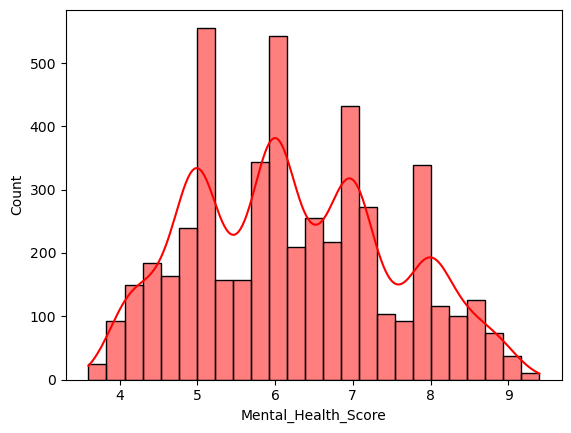

In [23]:
sns.histplot(df['Mental_Health_Score'],color='red',kde=True)

Correlation heatmap
Which numeric features actually move together with the target?

<Axes: >

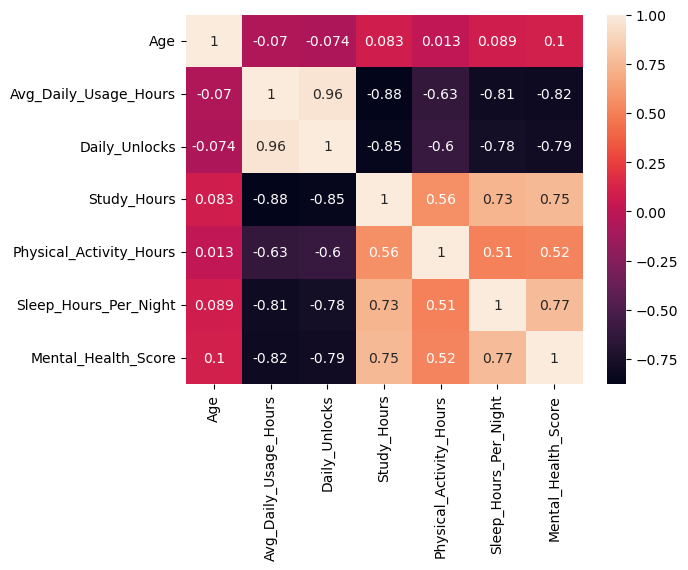

In [24]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Stress Level vs Mental Health Score
Does higher stress genuinely come with a lower score?

In [25]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

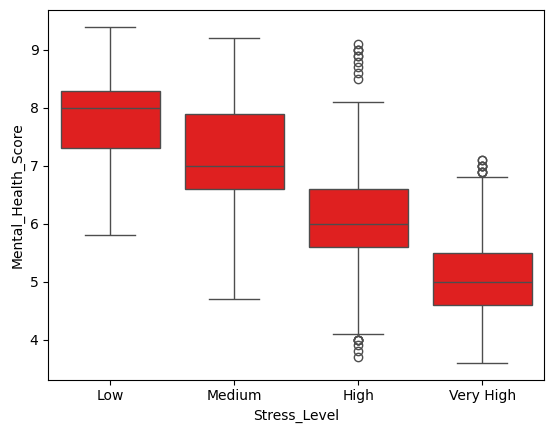

In [26]:
order=['Low','Medium',  'High', 'Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order,color='red')


Daily Usage Hours vs Mental Health Score
Does more time on social media relate to a lower score?

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

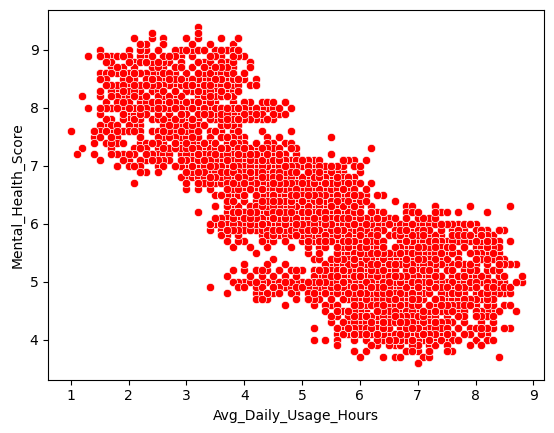

In [27]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df,color='red')

Sleep Hours vs Mental Health Score
Sleep is one of the most commonly cited mental health factors — does the data back that up? 

In [28]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

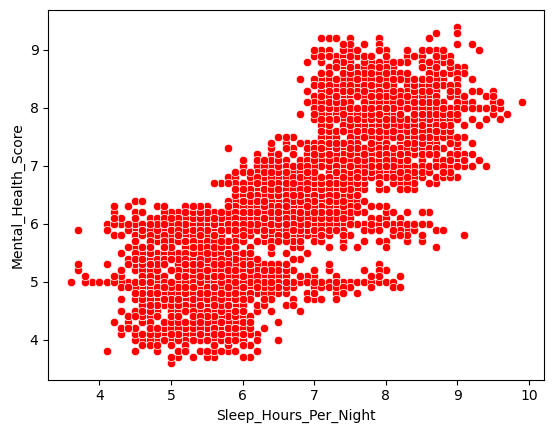

In [29]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df,color='red')

Most Used Platform (count)
A quick look at which platforms are most common in our dataset.

In [30]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

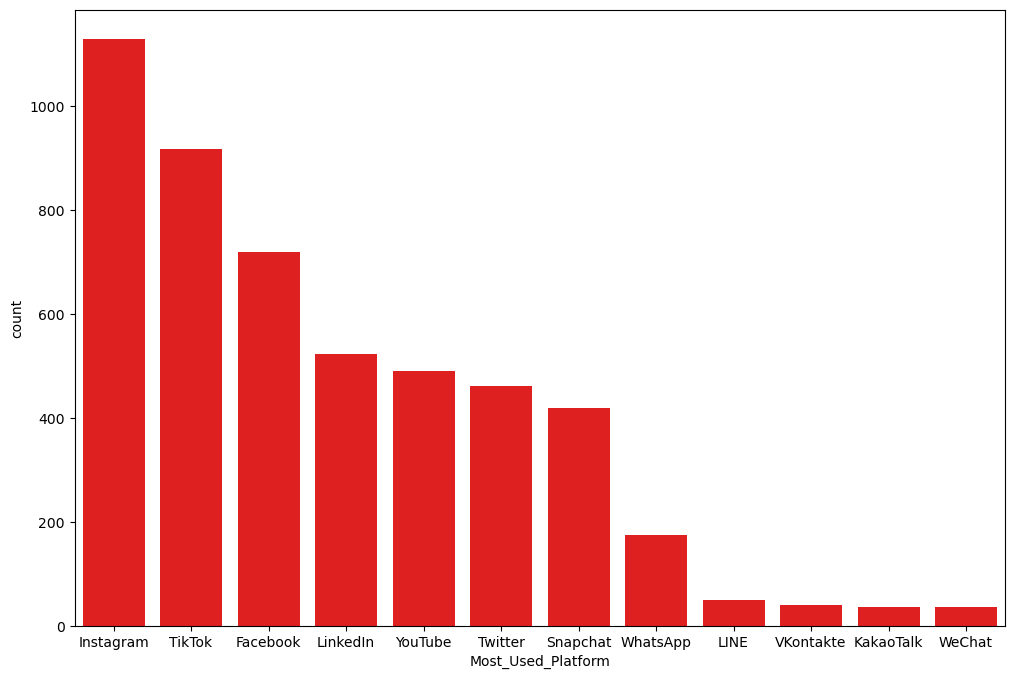

In [31]:
plt.figure(figsize=(12,8))
sns.countplot(x=df['Most_Used_Platform'],data=df,color='red',order=df['Most_Used_Platform'].value_counts().index)

Checking Outliers

In [33]:
 num_features=df.select_dtypes(include='number')
 Q1=num_features.quantile(0.25)
 Q3=num_features.quantile(0.75)
 IQR=Q3-Q1

 lower_bound=Q1-1.5*IQR
 upper_bound=Q3+1.5*IQR

outliers= (num_features<lower_bound) | (num_features>upper_bound)
print(outliers.sum())


Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


Data Cleaning
Two real issues to fix here — everything else in this dataset is already clean, so we don't manufacture cleaning steps that aren't needed.

In [34]:
#drop duplicates
df=df.drop_duplicates()

In [35]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


Why clip(lower=0) and not dropping the row: the rest of that student's data (age, study hours, stress level, etc.) is still valid and useful — throwing away the whole row over one bad value wastes good data. Clipping caps the impossible value at the nearest realistic one (0 hours) without discarding everything else about that student.

We're not dropping any columns either — every column here has a plausible reason to matter for predicting mental health, and we already confirmed none of them are empty or constant.

In [36]:
# Converting negative or unrealitstic value to realistic value
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

Skewness
What skewness is: a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

Why it matters: models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

In [39]:
num_cols=df.select_dtypes(include='number')
num_cols.skew()
#val-near 0--centralised, negative-left skewed, positive-right skewed

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

Feature Engineering
One meaningful engineered feature here: grouping Country.

Country has 111 unique values in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
Dropping Country entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
The fix: keep the top 10 most frequent countries as their own category, and bucket everything else into "Other". We keep the signal that matters and lose the noise that doesn't.

In [42]:
top_countries=df['Country'].value_counts().index[0:10].tolist()

In [43]:
def  group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [44]:
df['Grouped_Country']=df['Country'].apply(group_countries)

In [45]:
df['Grouped_Country']

0        Other
1        Other
2       Canada
3        Other
4        Other
         ...  
4995     Other
4996     Other
4997     India
4998     Other
4999     Other
Name: Grouped_Country, Length: 4998, dtype: object

Result: we went from 111 raw categories down to 11 manageable ones (10 countries + "Other"). This is exactly the kind of decision that separates a project that "just ran pd.get_dummies()" from one that actually thought about the data.

Encoding Strategy
Before we jump into code, let's decide how each categorical column should be encoded — this decision matters more than the code itself.

Stress_Level → Ordinal Encoding. Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
Gender, Academic_Level, Most_Used_Platform, Purpose_Of_Use, Country_Grouped → One-Hot Encoding. These categories have no natural order — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.
We'll implement both of these inside a single ColumnTransformer in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

Train-Test Split
Why we split: we need data the model has never seen to honestly check how well it generalizes. If we evaluate on the same data we trained on, the model can just "memorize" the answers and look artificially good.

Common ratios: 80/20 or 70/30 are both standard. We'll use an 80/20 split here — with 5,000 rows, that still leaves 1,000 rows for a solid, reliable test.

We split before fitting any preprocessing — this is the single most common beginner mistake (called data leakage), and we'll avoid it by fitting everything only on the training set.

In [55]:
from sklearn.model_selection import train_test_split

skewed_col=['Study_Hours']
other_numeric_cols=['Age','Avg_Daily_Usage_Hours','Daily_Unlocks','Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
ordinal_col=['Stress_Level']
normal_col=['Gender','Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use','Grouped_Country']

feature_col=skewed_col+other_numeric_cols+ordinal_col+normal_col
X= df[feature_col]
y=df['Mental_Health_Score']
_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

Preprocessing using ColumnTransformer
Our columns need different treatment:

Study_Hours (the skewed one) → impute → log1p transform → scale
The other numeric columns → impute → scale (no skew to fix)
Stress_Level → impute → OrdinalEncoder with an explicit order
The nominal columns → impute → OneHotEncoder
We include a SimpleImputer in every branch even though this dataset has zero missing values right now — it's a safety net. Real-world data (and our future API's incoming requests) won't always be this clean, and a pipeline that assumes "no missing values ever" is a pipeline that breaks in production.

ColumnTransformer glues all of this into one object that applies the right transformation to the right column type in a single .fit() / .transform() call — no manual column-by-column juggling

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#1. Skewed features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())

])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

#3. Ordinal
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])


preprocessor= ColumnTransformer(transformers=[
  ('Skewed_pipeline', skew_pipeline,skewed_col),
  ('Plain_numeric',plain_numeric_pipeline, other_numeric_cols),
  ('Ordinal', ordinal_pipeline,ordinal_col),
  ('Normal',nominal_pipeline,normal_col)
])

from IPython.display import display
display(preprocessor)


ColumnTransformer(transformers=[('Skewed_pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Plain_numeric',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('Normal',
                                 Pipeline(steps=[('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Grouped_Country'])])

Build a Pipeline
Why Pipeline matters: a Pipeline chains preprocessing and the model into a single object. Calling .fit() once does both steps in the correct order, and calling .predict() on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

Why companies prefer this: when this model gets deployed (which we're doing in Part 2 with FastAPI), the API doesn't need to know anything about scaling, encoding, or log transforms — it just loads one saved pipeline object and calls .predict() on raw input. That's a huge reduction in what can go wrong in production.

We'll build two pipelines below — one per model — so we can fairly compare them.

Model Building
We're comparing two models here because the comparison itself teaches something useful — a plain Linear Regression baseline versus a Random Forest, which can capture the non-linear patterns we spotted back in EDA (section 4.4).

Baseline: Linear Regression